# DRL Assignment 2
## Robust Reinforcement Learning under Stochastic Action Failure
### Team 238
### Environment : LunarLander-v3 (Gymnasium)

| Student Registration Number | Student Name | Percentage of Contribution |
|---|---|---|
| 2025AA05353 | SHEETAL PRAKASH BARANWAL | 100% |
| 2025AA05464 | CHIRANJEEV KIRAN | 100% |
| 2025AA05174 | AISHWARYA TEWARI | 100% |
| 2025AB05261 | AJAY KUMAR | 100% |
| 2025AB05046 | AISHWARYA SINGH | 100% |

## Objective

The objective of this assignment is to investigate the robustness of reinforcement
learning agents under stochastic action failures.

A custom environment wrapper is implemented over the original LunarLander-v3
environment. The wrapper introduces intermittent engine failures and modifies
the reward function while preserving all other properties of the original
environment.

The assignment consists of the following parts:

- Part (a): Modified Environment Wrapper
- Part (b): Deep Q-Network (DQN)
- Part (c): Double Deep Q-Network (DDQN)
- Part (d): Performance Evaluation
- Part (e): Discussion

In [1]:
# Initial Setup one time execution ONLY to setup 
#!pip install gymnasium
#!pip install gymnasium[box2d]
#!pip install torch torchvision torchaudio
#!pip install matplotlib
#!pip install numpy
#!pip install pandas
#!pip install tqdm


# ==========================================================
# Import Required Libraries
# ==========================================================

import gc

# Gymnasium is used to create reinforcement learning environments.
import gymnasium as gym

# NumPy is used for numerical computations. Numerical operations on states and rewards
import numpy as np

# Random module is used for reproducibility. Random sampling from the replay buffer and ε-greedy exploration
import random

# PyTorch is used for implementing Deep Neural Networks.
import torch                              # PyTorch framework for building the DQN
import torch.nn as nn                     # Neural network layers (Linear, ReLU, etc.)
import torch.optim as optim               # Optimizers such as Adam

# Deque is used for implementing Replay Memory. Efficient replay memory to store experiences
from collections import deque

# Matplotlib is used for plotting graphs.
import matplotlib.pyplot as plt

# Used for displaying training progress.
from tqdm import tqdm

# Ignore unnecessary warning messages.
import warnings
warnings.filterwarnings("ignore")

import gc 

In [2]:
# ==========================================================
# Set Random Seed
# ==========================================================

SEED = 42

# ==========================================================
# Global Hyperparameters
# ==========================================================
NUM_EPISODES = 750        # Change to 500 , #Nbr of episodes to run at final run
MOVING_AVG_WINDOW = 100     # As required by the assignment
EVAL_EPISODES = 100       # For evaluation function
LEARNING_RATE = 1e-3
GAMMA = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.997      # or 0.997 if you retrain
EPSILON_MIN = 0.01
BATCH_SIZE = 64
BUFFER_SIZE = 100000
TARGET_UPDATE = 5



random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random Seed :", SEED)

Random Seed : 42


In [3]:
# ==========================================================
# Device Configuration
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#print("PyTorch Version :", torch.__version__)
print("Running Device  :", device)

Running Device  : cpu


# Part (a): Modified Environment Wrapper

## Objective

The objective of Part (a) is to implement a custom environment wrapper over the
original LunarLander-v3 environment.

According to the assignment, the wrapper performs the following operations
for every call to `step(action)`:

1. Receive the Agent's Action
2. Simulate Intermittent Engine Failure
3. Execute the Action
4. Compute the Modified Reward
5. Safe Landing Bonus
6. Return the Environment Output

Except for the modifications described above, every other property of the
original environment must remain unchanged.

In [4]:
# ==========================================================
# Custom Environment Wrapper
# ==========================================================

class ModifiedLunarLanderWrapper(gym.Wrapper):
    """
    Custom wrapper for the LunarLander-v3 environment.

    This wrapper implements the modifications specified in the
    assignment while keeping all other components of the original
    environment unchanged.

    Assignment Steps:
        Step 1 : Receive the Agent's Action
        Step 2 : Simulate Intermittent Engine Failure
        Step 3 : Execute the Action
        Step 4 : Compute the Modified Reward
        Step 5 : Safe Landing Bonus
        Step 6 : Return the Environment Output
    """

    def __init__(self, env):
        """
        Constructor

        Parameters
        ----------
        env : gymnasium.Env
            Original LunarLander-v3 environment.
        """

        # Initialize parent wrapper
        super().__init__(env)

        print("✓ Modified LunarLander Wrapper Initialized")


    def step(self, action):
        """
        Executes one interaction with the environment.

        The implementation follows exactly the sequence specified
        in the assignment.
        """

        # ======================================================
        # STEP 1 : Receive the Agent's Action
        # ======================================================

        # Store the original action selected by the agent.
        # This action will later be used while computing
        # the modified reward.

        # The original action preserved because the
        # modified reward (Step 4) depends on the action
        # selected by the agent, NOT on the action that is
        # eventually executed after engine failure.
        
        original_action = action

        # (Optional) will uncomment the following line while debugging.
        # print(f"Original Action Selected by Agent : {original_action}")

        # ======================================================
        # STEP 2 : Simulate Intermittent Engine Failure (15% Probability)
        # ======================================================
        # If action == 0:
        #     Execute action without modification.
        #
        # Else:
        #     Generate random number r in [0,1)
        #     If r < 0.15:
        #         Replace action by 0
        #     Else:
        #         Execute original action.
        #
        # Store the final action as:
        # executed_action

        # If the selected action is "Do Nothing" (Action = 0),
        # execute it without any modification.
        if original_action == 0:

            executed_action = original_action

        # For thruster actions (1, 2, or 3),
        # simulate intermittent engine failure.
        else:

            # Generate a random number uniformly from [0, 1)
            random_number = np.random.random()

            # Engine failure occurs with probability 15%.
            if random_number < 0.15:

                # Replace the selected action by "Do Nothing".
                executed_action = 0

            else:

                # Execute the originally selected action.
                executed_action = original_action

        # (Optional) will uncomment while debugging.
        #
        #print(f"Original Action in Step 2 - Simulate Intermittent Engine Failure: {original_action}")
        #print(f"Executed Action in Step 2 - Simulate Intermittent Engine Failure: {executed_action}")



        # ======================================================
        # STEP 3 : Execute the Action
        # ======================================================

        # Execute the action using the original
        # LunarLander-v3 environment.
        #
        # Receive:
        # observation
        # base_reward
        # terminated
        # truncated
        # info
        
        # Execute the action determined after applying
        # the intermittent engine failure logic.

        observation, base_reward, terminated, truncated, info = self.env.step(executed_action)
        
        # (Optional) Uncomment while debugging.
        #
        #print("Executed Action - Step 3 Execute the Action:", executed_action)
        #print("Base Reward  - Step 3 Execute the Action:", base_reward)
        #print("Terminated  - Step 3 Execute the Action:", terminated)
        #print("Truncated  - Step 3 Execute the Action:", truncated)

        # ======================================================
        # STEP 4 : Compute the Modified Reward
        # ======================================================
        
        # Compute the modified reward using:
        #
        # modified_reward =
        #     base_reward
        #     - fuel_penalty
        #     + landing_bonus
        #
        # Fuel penalty depends on the ORIGINAL action,
        # not the executed action.
        
        # Determine the fuel penalty based on the ORIGINAL
        # action selected by the agent.
        
        if original_action == 0:
            fuel_penalty = 0.0
        elif original_action in [1, 2, 3]:
            fuel_penalty = 0.30  # Corrected from 0.03
        else:
            raise ValueError(f"Invalid action received: {original_action}")
        
         
        # Initialize landing bonus.
        # The actual bonus will be computed in Step 5.
        landing_bonus = 0.0
        
        # (Optional) will uncomment while debugging.
        #
        #print(f"Base Reward     - step 4 Compute the Modified Reward: {base_reward:.3f}")
        #print(f"Fuel Penalty    - step 4 Compute the Modified Reward: {fuel_penalty:.2f}")
        #print(f"Landing Bonus   - step 4 Compute the Modified Reward: {landing_bonus:.2f}")
        #print(f"Modified Reward - step 4 Compute the Modified Reward: {modified_reward:.3f}")


    
        # ======================================================
        # STEP 5 : Safe Landing Bonus and Store verification information in info dictionary
        # ======================================================

        # Award bonus of +50 only if ALL assignment
        # conditions are satisfied:
        #
        # terminated == True
        # truncated == False
        # observation[6] == 1
        # observation[7] == 1
        # abs(observation[2]) < 0.10
        # abs(observation[3]) < 0.10
        # abs(observation[4]) < 0.10

        safe_landing = (
            # Episode ended successfully (not still running)
            terminated
            # Episode did not end because of the time limit
            and not truncated
            # Left landing leg is touching the ground
            and observation[6] == 1
            # Right landing leg is touching the ground
            and observation[7] == 1
            # Horizontal velocity is sufficiently small
            and abs(observation[2]) < 0.10
            # Vertical velocity is sufficiently small
            and abs(observation[3]) < 0.10
            # Lander is nearly upright (small tilt angle)
            and abs(observation[4]) < 0.10
        )

        # Award safe landing bonus
        if safe_landing:
            landing_bonus = 50.0
        else:
            landing_bonus = 0.0

        # Compute the modified reward.
        modified_reward = base_reward - fuel_penalty + landing_bonus

        # (Optional) will uncomment while debugging.
        #
        #print(f"Landing Bonus   - Step 5 Safe Landing Bonus: {landing_bonus}")
        #print(f"Modified Reward - Step 5 Safe Landing Bonus: {modified_reward:.3f}")
        
        # ======================================================
        # STEP 6 : Return the Environment Output
        # ======================================================
        
        # Return the modified environment output.
        # observation
        # modified_reward
        # terminated
        # truncated
        # info
        # The original reward is replaced by the modified reward,
        # while all other values remain unchanged.
        return (
            observation,
            modified_reward,
            terminated,
            truncated,
            info
        )

In [5]:
# ==========================================================
# Custom Environment Wrapper
# ==========================================================

class ModifiedLunarLanderWrapper(gym.Wrapper):
    """
    Custom wrapper for the LunarLander-v3 environment.

    This wrapper implements the modifications specified in the
    assignment while keeping all other components of the original
    environment unchanged.

    Assignment Steps:
        Step 1 : Receive the Agent's Action
        Step 2 : Simulate Intermittent Engine Failure
        Step 3 : Execute the Action
        Step 4 : Compute the Modified Reward
        Step 5 : Safe Landing Bonus
        Step 6 : Return the Environment Output
    """

    def __init__(self, env):
        super().__init__(env)
        print("✓ Modified LunarLander Wrapper Initialized")

    def step(self, action):

        # ==========================================================
        # STEP 1 : Receive the Agent's Action
        # ==========================================================
        original_action = action

        # ==========================================================
        # STEP 2 : Simulate Intermittent Engine Failure
        # 15% probability that any thruster action (1,2,3)
        # is replaced with Action 0 (Do Nothing).
        # ==========================================================
        if original_action == 0:
            executed_action = 0
        else:
            random_number = np.random.random()

            if random_number < 0.15:
                executed_action = 0
            else:
                executed_action = original_action

        # ==========================================================
        # STEP 3 : Execute the Action
        # ==========================================================
        observation, base_reward, terminated, truncated, info = self.env.step(executed_action)

        # ==========================================================
        # STEP 4 : Compute Fuel Penalty
        # Every attempted thruster action (1, 2, or 3)
        # incurs a penalty of 0.30 irrespective of whether
        # the engine actually fires or misfires.
        # ==========================================================
        if original_action == 0:
            fuel_penalty = 0.0
        else:
            fuel_penalty = 0.30

        # ==========================================================
        # STEP 5 : Safe Landing Bonus
        # Award +50 only if ALL safe landing conditions are met.
        # ==========================================================
        safe_landing = (
            terminated
            and not truncated
            and observation[6] == 1.0
            and observation[7] == 1.0
            and abs(observation[2]) < 0.10
            and abs(observation[3]) < 0.10
            and abs(observation[4]) < 0.10
        )

        landing_bonus = 50.0 if safe_landing else 0.0

        # Final Modified Reward
        # R = R_base - Fuel Penalty + Landing Bonus
        modified_reward = (
            base_reward
            - fuel_penalty
            + landing_bonus
        )

        # ==========================================================
        # STEP 6 : Return the Environment Output
        # Do NOT modify the info dictionary.
        # ==========================================================
        return (
            observation,
            modified_reward,
            terminated,
            truncated,
            info
        )

## Task (a): Verification 1: Intermittent Engine Failure

This verification checks whether the wrapper correctly implements the
15% probability of engine failure for thruster actions (Actions 1, 2, and 3).

A large number of trials are executed, and the observed engine failure
rate is compared with the expected probability of 15%.

In [6]:
# ==========================================================
# Debug Wrapper (Verification Only)
# ==========================================================
# This class reproduces the final wrapper logic but returns
# additional diagnostic information required for Verification
# 1–3. It is NOT used during training or final evaluation.
# ==========================================================


# ==========================================================
# Debug Wrapper (Verification Only)
# ==========================================================
# This class reproduces the final wrapper logic but returns
# additional diagnostic information required for Verification
# 1–3. It is NOT used during training or final evaluation.
# ==========================================================

class DebugModifiedLunarLanderWrapper(ModifiedLunarLanderWrapper):

    def step(self, action):

        # Step 1 : Store agent's selected action
        original_action = action

        # Step 2 : Simulate engine failure
        if original_action == 0:
            executed_action = 0
        else:
            if np.random.random() < 0.15:
                executed_action = 0
            else:
                executed_action = original_action

        # Step 3 : Execute action
        observation, base_reward, terminated, truncated, info = self.env.step(executed_action)

        # Step 4 : Fuel penalty
        fuel_penalty = 0.0 if original_action == 0 else 0.30

        # Step 5 : Safe landing bonus
        safe_landing = (
            terminated
            and not truncated
            and observation[6] == 1.0
            and observation[7] == 1.0
            and abs(observation[2]) < 0.10
            and abs(observation[3]) < 0.10
            and abs(observation[4]) < 0.10
        )

        landing_bonus = 50.0 if safe_landing else 0.0

        # Step 6 : Modified reward
        modified_reward = (
            base_reward
            - fuel_penalty
            + landing_bonus
        )

        # Diagnostic information returned only for verification.
        # The final assignment wrapper does NOT expose these values.
        debug_info = {
            "original_action": original_action,
            "executed_action": executed_action,
            "original_reward": base_reward,
            "fuel_penalty": fuel_penalty,
            "landing_bonus": landing_bonus,
            "modified_reward": modified_reward,
            "safe_landing": safe_landing
        }

        return (
            observation,
            modified_reward,
            terminated,
            truncated,
            debug_info
        )

In [7]:
# ==========================================================
# Verification 1 : Engine Failure Probability
# ==========================================================

env = DebugModifiedLunarLanderWrapper(gym.make("LunarLander-v3"))

env.reset(seed=SEED)

num_trials = 20000
engine_failures = 0

for _ in range(num_trials):

    # Randomly choose a thruster action
    action = np.random.choice([1, 2, 3])

    observation, reward, terminated, truncated, info = env.step(action)

    # Count engine failures
    if info["executed_action"] == 0:
        engine_failures += 1

    if terminated or truncated:
        env.reset()

observed_failure_rate = engine_failures / num_trials

print("=" * 70)
print("Verification 1 : Engine Failure Probability")
print("=" * 70)

print(f"Number of Trials        : {num_trials}")
print(f"Engine Failures         : {engine_failures}")
print(f"Observed Failure Rate   : {observed_failure_rate:.4f}")
print(f"Expected Failure Rate   : 0.1500")

env.close()


# ==========================================================
# Observation
# ==========================================================

print("\n" + "=" * 70)
print("Observation")
print("=" * 70)

TOLERANCE = 0.01
difference = abs(observed_failure_rate - 0.15)

if difference <= TOLERANCE:
    print(
        f"The observed engine failure rate ({observed_failure_rate:.4f}) "
        "is very close to the expected probability of 0.15.\n"
        "This confirms that the intermittent engine failure mechanism "
        "has been implemented correctly."
    )
else:
    print(
        f"The observed engine failure rate ({observed_failure_rate:.4f}) "
        "differs noticeably from the expected probability of 0.15.\n"
        "Increasing the number of trials should produce a value "
        "closer to the expected probability."
    )

✓ Modified LunarLander Wrapper Initialized
Verification 1 : Engine Failure Probability
Number of Trials        : 20000
Engine Failures         : 2974
Observed Failure Rate   : 0.1487
Expected Failure Rate   : 0.1500

Observation
The observed engine failure rate (0.1487) is very close to the expected probability of 0.15.
This confirms that the intermittent engine failure mechanism has been implemented correctly.


## Task (a) : Verification 2: Fuel Penalty

This verification confirms that the wrapper correctly applies the fuel
penalty based on the **original action selected by the agent**.

The printed values show:

- Original Reward (reward from the original environment)
- Fuel Penalty
- Modified Reward

The modified reward should satisfy:

Modified Reward = Original Reward − Fuel Penalty + Landing Bonus

In [8]:
# ==========================================================
# Verification 2 : Fuel Penalty
# ==========================================================

env = DebugModifiedLunarLanderWrapper(gym.make("LunarLander-v3"))

observation, _ = env.reset(seed=SEED)

successful_fire = None
engine_failure = None

MAX_STEPS = 1000

for _ in range(MAX_STEPS):

    # Always attempt a thruster action
    action = 2

    observation, modified_reward, terminated, truncated, info = env.step(action)

    # Case 1 : Thruster executed successfully
    if (
        info["original_action"] == 2
        and info["executed_action"] == 2
        and successful_fire is None
    ):
        successful_fire = info.copy()

    # Case 2 : Thruster misfired
    if (
        info["original_action"] == 2
        and info["executed_action"] == 0
        and engine_failure is None
    ):
        engine_failure = info.copy()

    if successful_fire is not None and engine_failure is not None:
        break

    if terminated or truncated:
        observation, _ = env.reset()

env.close()

print("=" * 70)
print("Verification 2 : Fuel Penalty")
print("=" * 70)


# ==========================================================
# Helper Function
# ==========================================================

def verify_case(title, data):

    print(f"\n{title}")
    print("-" * 70)

    print(f"Original Action : {data['original_action']}")
    print(f"Executed Action : {data['executed_action']}")
    print(f"Original Reward : {data['original_reward']:.3f}")
    print(f"Fuel Penalty    : {data['fuel_penalty']:.3f}")
    print(f"Landing Bonus   : {data['landing_bonus']:.3f}")
    print(f"Modified Reward : {data['modified_reward']:.3f}")

    calculated_reward = (
        data["original_reward"]
        - data["fuel_penalty"]
        + data["landing_bonus"]
    )

    print("\nReward Verification")
    print("-" * 70)

    print(
        f"Modified Reward = {data['original_reward']:.3f}"
        f" - {data['fuel_penalty']:.3f}"
        f" + {data['landing_bonus']:.3f}"
    )

    print(f"Calculated Reward : {calculated_reward:.3f}")
    print(f"Wrapper Reward    : {data['modified_reward']:.3f}")

    if abs(calculated_reward - data["modified_reward"]) < 1e-6:
        print("Verification      : PASS ✓")
    else:
        print("Verification      : FAIL ✗")


# ==========================================================
# Case 1 : Thruster Fired Successfully
# ==========================================================

if successful_fire is not None:

    verify_case(
        "Case 1 : Thruster Fired Successfully",
        successful_fire
    )

else:

    print("\nCase 1 : Thruster Fired Successfully")
    print("-" * 70)
    print("No successful thruster execution was observed.")


# ==========================================================
# Case 2 : Engine Misfire
# ==========================================================

if engine_failure is not None:

    verify_case(
        "Case 2 : Engine Misfire (Executed as Do Nothing)",
        engine_failure
    )

else:

    print("\nCase 2 : Engine Misfire")
    print("-" * 70)
    print("No engine misfire was observed.")


# ==========================================================
# Observation
# ==========================================================

print("\n" + "=" * 70)
print("Observation")
print("=" * 70)

print(
    "• The fuel penalty depends on the action selected by the agent, "
    "not on the action actually executed."
)

print(
    "• The fuel penalty remained 0.300 in both cases because the "
    "agent selected a thruster action, even when the executed action "
    "became Do Nothing due to an engine misfire."
)

print(
    "• In both cases, the independently calculated reward exactly "
    "matched the reward returned by the wrapper."
)

print(
    "• These experimental results confirm that the wrapper correctly "
    "applies the fuel penalty for every attempted thruster action, "
    "irrespective of whether the engine fires successfully or "
    "misfires, as specified in the assignment."
)

✓ Modified LunarLander Wrapper Initialized
Verification 2 : Fuel Penalty

Case 1 : Thruster Fired Successfully
----------------------------------------------------------------------
Original Action : 2
Executed Action : 2
Original Reward : -4.401
Fuel Penalty    : 0.300
Landing Bonus   : 0.000
Modified Reward : -4.701

Reward Verification
----------------------------------------------------------------------
Modified Reward = -4.401 - 0.300 + 0.000
Calculated Reward : -4.701
Wrapper Reward    : -4.701
Verification      : PASS ✓

Case 2 : Engine Misfire (Executed as Do Nothing)
----------------------------------------------------------------------
Original Action : 2
Executed Action : 0
Original Reward : 1.145
Fuel Penalty    : 0.300
Landing Bonus   : 0.000
Modified Reward : 0.845

Reward Verification
----------------------------------------------------------------------
Modified Reward = 1.145 - 0.300 + 0.000
Calculated Reward : 0.845
Wrapper Reward    : 0.845
Verification      : PASS 

## Task (a) : Verification 3: Safe Landing Bonus

This verification checks whether the wrapper correctly awards the
+50 safe landing bonus.

Whenever a safe landing occurs, the wrapper stores:

- Safe Landing Status
- Landing Bonus
- Modified Reward

The landing bonus should be +50 only when all assignment conditions
for a safe landing are satisfied.

In [9]:
# ==========================================================
# Verification 3 : Safe Landing Bonus
# ==========================================================

import time

env = DebugModifiedLunarLanderWrapper(gym.make("LunarLander-v3"))

MAX_EPISODES = 1000

safe_landing_info = None
unsafe_landing_info = None

# Seed the environment only once
env.reset(seed=SEED)

episode_count = 0
start_time = time.time()

while (
    episode_count < MAX_EPISODES
    and (safe_landing_info is None or unsafe_landing_info is None)
):

    episode_count += 1

    observation, _ = env.reset()

    done = False

    while not done:

        # Random policy for verification
        action = env.action_space.sample()

        observation, modified_reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Store first unsafe landing example
        if (
            done
            and not info["safe_landing"]
            and unsafe_landing_info is None
        ):
            unsafe_landing_info = info.copy()

        # Store first safe landing example
        if (
            info["safe_landing"]
            and safe_landing_info is None
        ):
            safe_landing_info = info.copy()

elapsed_time = time.time() - start_time

env.close()

print("=" * 70)
print("Verification 3 : Landing Bonus")
print("=" * 70)


# ==========================================================
# Helper Function
# ==========================================================

def verify_case(case_name, data):

    print(f"\n{case_name}")
    print("-" * 70)

    print(f"Safe Landing Flag : {data['safe_landing']}")
    print(f"Landing Bonus     : {data['landing_bonus']:.3f}")
    print(f"Original Reward   : {data['original_reward']:.3f}")
    print(f"Fuel Penalty      : {data['fuel_penalty']:.3f}")
    print(f"Modified Reward   : {data['modified_reward']:.3f}")

    calculated_reward = (
        data["original_reward"]
        - data["fuel_penalty"]
        + data["landing_bonus"]
    )

    expected_bonus = 50.0 if data["safe_landing"] else 0.0

    reward_correct = (
        abs(calculated_reward - data["modified_reward"]) < 1e-6
    )

    bonus_correct = (
        abs(expected_bonus - data["landing_bonus"]) < 1e-6
    )

    print("\nReward Verification")
    print(
        f"Modified Reward = {data['original_reward']:.3f}"
        f" - {data['fuel_penalty']:.3f}"
        f" + {data['landing_bonus']:.3f}"
    )

    print(f"Calculated Reward : {calculated_reward:.3f}")
    print(f"Wrapper Reward    : {data['modified_reward']:.3f}")

    if reward_correct and bonus_correct:
        print("Verification      : PASS ✓")
    else:
        print("Verification      : FAIL ✗")


# ==========================================================
# Case 1 : No Safe Landing
# ==========================================================

if unsafe_landing_info is not None:

    verify_case(
        "Case 1 : No Safe Landing",
        unsafe_landing_info
    )

else:

    print("\nCase 1 : No Safe Landing")
    print("-" * 70)
    print("No unsafe landing example was captured during verification.")


# ==========================================================
# Case 2 : Safe Landing
# ==========================================================

if safe_landing_info is not None:

    verify_case(
        "Case 2 : Safe Landing",
        safe_landing_info
    )

else:

    print("\nCase 2 : Safe Landing")
    print("-" * 70)
    print(
        f"No safe landing was observed within {MAX_EPISODES} "
        "episodes using the random policy."
    )

    print(
        "This does not indicate an implementation error. "
        "Random actions rarely achieve successful landings "
        "in LunarLander-v3."
    )


# ==========================================================
# Observation
# ==========================================================

print("\n" + "=" * 70)
print("Observation")
print("=" * 70)

if unsafe_landing_info is not None:

    print(
        "• The wrapper correctly withheld the +50 landing bonus "
        "when the safe landing conditions were not satisfied."
    )

if safe_landing_info is not None:

    print(
        "• The wrapper correctly awarded the +50 landing bonus "
        "when all safe landing conditions were satisfied."
    )

if safe_landing_info is None:

    print(
        "• A safe landing was not observed during random-policy "
        "execution. This is expected because a random policy "
        "rarely lands successfully in LunarLander-v3."
    )

print(
    "• For every observed case, the independently calculated "
    "reward exactly matched the reward returned by the wrapper."
)

print(
    "• This confirms that the reward modification logic was "
    "implemented correctly for the observed simulation cases."
)

print(f"\nEpisodes Executed : {episode_count}")
print(f"Execution Time    : {elapsed_time:.2f} seconds")

✓ Modified LunarLander Wrapper Initialized
Verification 3 : Landing Bonus

Case 1 : No Safe Landing
----------------------------------------------------------------------
Safe Landing Flag : False
Landing Bonus     : 0.000
Original Reward   : -100.000
Fuel Penalty      : 0.300
Modified Reward   : -100.300

Reward Verification
Modified Reward = -100.000 - 0.300 + 0.000
Calculated Reward : -100.300
Wrapper Reward    : -100.300
Verification      : PASS ✓

Case 2 : Safe Landing
----------------------------------------------------------------------
Safe Landing Flag : True
Landing Bonus     : 50.000
Original Reward   : -100.000
Fuel Penalty      : 0.300
Modified Reward   : -50.300

Reward Verification
Modified Reward = -100.000 - 0.300 + 50.000
Calculated Reward : -50.300
Wrapper Reward    : -50.300
Verification      : PASS ✓

Observation
• The wrapper correctly withheld the +50 landing bonus when the safe landing conditions were not satisfied.
• The wrapper correctly awarded the +50 landin

In [10]:
# Dedicated environment for creating validation states
validation_env = gym.make("LunarLander-v3")

validation_states = []

state, _ = validation_env.reset(seed=42)

for _ in range(100):

    validation_states.append(state.copy())

    action = validation_env.action_space.sample()

    next_state, reward, terminated, truncated, _ = validation_env.step(action)

    state = next_state

    if terminated or truncated:
        state, _ = validation_env.reset()

validation_states = torch.FloatTensor(np.array(validation_states))

validation_env.close()

print(validation_states.shape)

torch.Size([100, 8])


In [11]:
def evaluate_q_values(agent, validation_states):

    agent.q_network.eval()

    with torch.no_grad():

        q_values = agent.q_network(validation_states)

        avg_q = q_values.max(dim=1)[0].mean().item()

    agent.q_network.train()

    return avg_q

# Part (b): Replay Buffer

## What is a Replay Buffer?

A **Replay Buffer** is a memory used by the DQN agent to store its past experiences while interacting with the environment. Instead of learning only from the latest experience, the agent learns from a random collection of previous experiences, which makes training more stable and efficient.

Each stored experience (also called a **transition**) has the following format:

```
(Current State, Action, Reward, Next State, Done)
```

For example,

```
(S1, 2, +1.65, S2, False)
```

where:

- **State (S1)** → Current state of the LunarLander.
- **Action (2)** → Action selected by the agent.
- **Reward (+1.65)** → Reward received after taking the action.
- **Next State (S2)** → State after executing the action.
- **Done (False)** → Indicates whether the episode has ended.

---

## How the Replay Buffer Works

### Step 1: Agent interacts with the environment

```
Current State (S1)
        │
        ▼
Choose Action (2)
        │
        ▼
Environment
        │
        ▼
Reward = +1.65
Next State = S2
Done = False
```

The generated experience is stored in the Replay Buffer.

```
(S1, 2, +1.65, S2, False)
```

---

### Step 2: More experiences are collected

As the agent continues interacting with the environment, the Replay Buffer stores more experiences.

```
Experience 1 : (S1,2,+1.65,S2,False)

Experience 2 : (S2,1,-0.30,S3,False)

Experience 3 : (S3,0,-1.20,S4,False)

...
```

---

### Step 3: Fixed Buffer Capacity

The Replay Buffer has a fixed maximum capacity.

For example,

```python
ReplayBuffer(capacity=5)
```

Initially, the buffer contains

```
Experience 1
Experience 2
Experience 3
Experience 4
Experience 5
```

When a new experience (Experience 6) is added,

```
Experience 2
Experience 3
Experience 4
Experience 5
Experience 6
```

The **oldest experience (Experience 1)** is automatically removed, and the newest experience is stored. This is handled automatically by **deque(maxlen=capacity)**.

---

### Step 4: Random Sampling for Training

Instead of learning from only the latest experience, the DQN randomly samples a mini-batch from the Replay Buffer.

For example,

```python
batch = replay_buffer.sample(4)
```

may randomly return

```
Experience 8
Experience 2
Experience 10
Experience 5
```

Notice that the sampled experiences are **random** rather than consecutive.

---

## Why Use Random Sampling?

Consecutive experiences are highly correlated because they occur one after another in the same episode. Training on only consecutive experiences can make learning unstable.

Random sampling:

- Breaks the correlation between consecutive experiences.
- Reuses previous experiences multiple times.
- Improves learning stability.
- Increases the efficiency of the DQN algorithm.

Therefore, the Replay Buffer is one of the key components that makes **Deep Q-Network (DQN)** more stable and effective than learning only from the most recent experience.

In [12]:
# ==========================================================
# Part (b): Replay Buffer
# ==========================================================

#Part (b): Deep Q-Network (DQN) Agent
#Part B.1: Replay Buffer
#Code: ReplayBuffer class.

class ReplayBuffer:

    def __init__(self, capacity):
        """
        Initialize the Replay Buffer.

        Parameters:
            capacity : Maximum number of experiences the buffer can store.
        """

        # Create a double-ended queue (deque).
        # maxlen=capacity means:
        # - When the buffer becomes full,
        # - the oldest experience is automatically removed,
        # - and the newest experience is added.
        self.memory = deque(maxlen=capacity)


    def add(self, state, action, reward, next_state, done):
        """
        Store one experience (transition) in the replay buffer.

        Experience Format:
        (Current State, Action, Reward, Next State, Episode Finished)

        Example:
        ([0.2, 1.1, ...], 2, 1.65, [0.3, 1.0, ...], False)
        """

        # Add the new experience at the end of the replay buffer.
        self.memory.append((state, action, reward, next_state, done))


    def sample(self, batch_size):
        """
        Randomly select a mini-batch of experiences for training.

        Why random sampling?
        --------------------
        Consecutive experiences are highly correlated.
        Random sampling breaks this correlation and makes
        DQN training more stable.

        Example:
        If batch_size = 64,
        randomly return 64 experiences from the buffer.
        """

        return random.sample(self.memory, batch_size)


    def __len__(self):
        """
        Return the current number of experiences stored
        in the replay buffer.

        Example:
        If 350 experiences have been stored,
        len(replay_buffer) returns 350.
        """

        return len(self.memory)

# Task (b): Build the DQN Neural Network

## What is the DQN Network?

The Deep Q-Network (DQN) is a neural network that approximates the Q-function. Instead of storing a Q-value for every state-action pair in a table, the network predicts the Q-values for all possible actions given the current state.

For the LunarLander-v3 environment:

- **Input:** 8 state variables
- **Hidden Layers:** Fully connected layers with ReLU activation
- **Output:** 4 Q-values (one for each possible action)

The agent selects the action corresponding to the highest predicted Q-value.

```
State (8 values)
        │
        ▼
Input Layer (8 neurons)
        │
        ▼
Hidden Layer 1
(128 neurons + ReLU)
        │
        ▼
Hidden Layer 2
(128 neurons + ReLU)
        │
        ▼
Output Layer (4 neurons)
        │
        ▼
Q(s,0)  Q(s,1)  Q(s,2)  Q(s,3)
```

The action with the highest Q-value is selected during exploitation.

In [13]:
# ==========================================================
# Part (b): Deep Q-Network (DQN)
# ==========================================================
#Part B.2: Deep Q-Network (DQN)
#Code: DQN class.


class DQN(nn.Module):

    def __init__(self, state_size, action_size):
        """
        Initialize the Deep Q-Network.

        Parameters:
            state_size  : Number of state features.
            action_size : Number of possible actions.
        """

        super(DQN, self).__init__()

        # First fully connected layer
        self.fc1 = nn.Linear(state_size, 128)

        # Second fully connected layer
        self.fc2 = nn.Linear(128, 128)

        # Output layer
        # Produces one Q-value for each possible action
        self.fc3 = nn.Linear(128, action_size)


    def forward(self, state):
        """
        Forward pass through the network.

        Input:
            state

        Output:
            Q-values for all possible actions.
        """

        # Hidden Layer 1
        x = torch.relu(self.fc1(state))

        # Hidden Layer 2
        x = torch.relu(self.fc2(x))

        # Output Layer
        q_values = self.fc3(x)

        return q_values

# Part (b).1: DQN Agent

## What is a DQN Agent?

The DQN Agent is responsible for interacting with the environment and learning the optimal policy.

It combines the following components:

- Replay Buffer
- Online (Q) Network
- Target Network
- Adam Optimizer
- Loss Function
- Hyperparameters (γ, ε, batch size, etc.)

### Workflow

```
Current State
      │
      ▼
Online Q-Network
      │
      ▼
Predict Q-values
      │
      ▼
Select Action
      │
      ▼
Interact with Environment
      │
      ▼
Store Experience
      │
      ▼
Replay Buffer
      │
      ▼
Sample Mini-Batch
      │
      ▼
Train Q-Network
      │
      ▼
Update Target Network
```

In [14]:
# ==========================================================
# Part (b): Deep Q-Network (DQN) Agent
# ==========================================================
# Implements:
#   Part (b).3: DQN Agent Initialization
#   Part (b).4: ε-Greedy Action Selection
#   Part (b).5: Store Experience
#   Part (b).6: Learn from Replay Buffer
#   Part (b).7: Update Target Network
#   Part (b).8: Decay Exploration Rate
# ==========================================================

class DQNAgent:

    # ======================================================
    # Part (b).3: DQN Agent Initialization
    # ======================================================
    def __init__(self,
                 state_size,
                 action_size,
                 learning_rate=LEARNING_RATE,
                 gamma=GAMMA,
                 epsilon=EPSILON,
                 epsilon_decay=EPSILON_DECAY,
                 epsilon_min=EPSILON_MIN,
                 batch_size=BATCH_SIZE,
                 buffer_size=BUFFER_SIZE):

        """
        Initialize the DQN Agent.

        Parameters:
            state_size      : Number of state features.
            action_size     : Number of possible actions.
            learning_rate   : Learning rate for the optimizer.
            gamma           : Discount factor.
            epsilon         : Initial exploration rate.
            epsilon_decay   : Exploration decay factor.
            epsilon_min     : Minimum exploration rate.
            batch_size      : Mini-batch size.
            buffer_size     : Replay Buffer capacity.
        """

        # Environment information
        self.state_size = state_size
        self.action_size = action_size

        # Hyperparameters
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size

        # Replay Buffer
        self.memory = ReplayBuffer(buffer_size)

        # Online Network
        self.q_network = DQN(state_size, action_size)

        # Target Network
        self.target_network = DQN(state_size, action_size)

        # Copy weights from Online Network to Target Network
        self.target_network.load_state_dict(
            self.q_network.state_dict()
        )

        # Optimizer
        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=learning_rate
        )

        # Loss Function
        self.loss_function = nn.MSELoss()

    # ======================================================
    # Part (b).4: ε-Greedy Action Selection
    # ======================================================
    def select_action(self, state):

        if random.random() < self.epsilon:
            return random.randrange(self.action_size)

        state = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state)

        return torch.argmax(q_values).item()

    # ======================================================
    # Part (b).5: Store Experience
    # ======================================================
    def remember(self, state, action, reward, next_state, done):

        self.memory.add(state, action, reward, next_state, done)

    # ======================================================
    # Part (b).6: Learn from Replay Buffer
    # ======================================================
    def learn(self):

        if len(self.memory) < self.batch_size:
            return

        batch = self.memory.sample(self.batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # Current Q-values
        current_q = self.q_network(states).gather(1, actions)

        # Target Q-values
        with torch.no_grad():
            max_next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)

        target_q = rewards + self.gamma * max_next_q * (1 - dones)

        loss = self.loss_function(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    # ======================================================
    # Part (b).7: Update Target Network
    # ======================================================
    def update_target_network(self):

        self.target_network.load_state_dict(
            self.q_network.state_dict()
        )

    # ======================================================
    # Part (b).8: Decay Exploration Rate
    # ======================================================
    def decay_epsilon(self):

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

            if self.epsilon < self.epsilon_min:
                self.epsilon = self.epsilon_min

## Part B.4: ε-Greedy Action Selection

### What is ε-Greedy Policy?

The ε-Greedy policy balances **exploration** and **exploitation** during training.

- **Exploration:** The agent selects a random action to discover new experiences.
- **Exploitation:** The agent selects the action with the highest predicted Q-value from the DQN.

The parameter **ε (epsilon)** controls this balance.

- If a random number is less than ε, the agent explores.
- Otherwise, it exploits the current knowledge.

Initially, ε is set to **1.0**, meaning the agent explores almost all the time.

As training progresses, ε gradually decreases until it reaches the minimum value, allowing the agent to exploit its learned policy more frequently.

### Decision Process

```
Current State
      │
      ▼
Generate Random Number
      │
      ▼
Is Random < ε ?
     / \
   Yes  No
   /      \
Random   DQN Prediction
Action      │
            ▼
      Choose Highest Q-value

```

## Part B.5: Store Experience in Replay Buffer

### Purpose

During training, the DQN Agent interacts with the environment by taking actions and observing their outcomes. Each interaction is called an **experience**.

An experience consists of:

- **State (s):** Current state of the environment.
- **Action (a):** Action selected by the agent.
- **Reward (r):** Immediate reward received after taking the action.
- **Next State (s'):** State reached after executing the action.
- **Done:** Indicates whether the episode has terminated.

Each experience is stored in the Replay Buffer so that it can be reused during training. This process is known as **Experience Replay**.

### Experience Format

```
(State, Action, Reward, Next State, Done)

Example:

([0.10, -0.25, ...], 2, +5.0,
 [0.15, -0.18, ...], False)
```

Instead of learning immediately from each experience, the agent stores many experiences and later samples a random mini-batch for training. This improves learning stability by reducing the correlation between consecutive experiences.



## Part B.6: Learning from Experience (Experience Replay)

### Purpose

The DQN Agent learns by sampling a random mini-batch of experiences from the Replay Buffer instead of learning from only the latest experience.

Each sampled experience consists of:

(State, Action, Reward, Next State, Done)

For every experience in the mini-batch, the agent performs the following steps:

1. Predict the current Q-value using the Online Q-Network.
2. Compute the target Q-value using the Target Network.
3. Calculate the Mean Squared Error (MSE) loss.
4. Perform backpropagation to update the Online Network.

Random sampling reduces the correlation between consecutive experiences and results in more stable and efficient learning.

### Learning Process

```
Replay Buffer
      │
      ▼
Random Mini-Batch
      │
      ▼
Online Network
(Current Q-values)
      │
      ▼
Target Network
(Target Q-values)
      │
      ▼
Calculate Loss
      │
      ▼
Backpropagation
      │
      ▼
Update Online Network
```


## Part B.7: Update Target Network

### Purpose

The DQN algorithm uses two neural networks:

1. **Online Q-Network:** Learns continuously during training.
2. **Target Q-Network:** Provides stable target Q-values for learning.

If the target values change after every update, the learning process becomes unstable. Therefore, the Target Network is updated periodically by copying the weights from the Online Network.

### Target Network Update

```
Online Q-Network
        │
        │ Copy Weights
        ▼
Target Q-Network
```

The Target Network does not learn directly. Instead, it periodically receives the latest weights from the Online Network to improve training stability.


## Part B.8: Train the DQN Agent

### Purpose

The objective of training is to enable the DQN Agent to learn an optimal policy for solving the LunarLander-v3 environment.

During each training episode, the following steps are performed:

1. Reset the environment.
2. Observe the initial state.
3. Select an action using the ε-Greedy policy.
4. Execute the selected action.
5. Receive the reward and next state.
6. Store the experience in the Replay Buffer.
7. Learn from a randomly sampled mini-batch.
8. Repeat until the episode terminates.
9. Update the Target Network periodically.
10. Reduce the exploration rate (ε).

The cumulative reward obtained during each episode is recorded to monitor the learning progress of the agent.

### Training Workflow

```
Reset Environment
        │
        ▼
Observe Current State
        │
        ▼
Select Action (ε-Greedy)
        │
        ▼
Execute Action
        │
        ▼
Receive Reward & Next State
        │
        ▼
Store Experience
        │
        ▼
Learn from Replay Buffer
        │
        ▼
Update Target Network
        │
        ▼
Decay ε
        │
        ▼
Next Episode
```

In [15]:
# ==========================================================
# Part B.8 (a): Train the DQN Agent on modified LunarLander environment
# ==========================================================

# Create the modified LunarLander environment
env = ModifiedLunarLanderWrapper(gym.make("LunarLander-v3"))

# Environment information
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Create the DQN Agent
agent_modified = DQNAgent(
    state_size=state_size,
    action_size=action_size
)

# Training Parameters
num_episodes = NUM_EPISODES
target_update = 5

episode_rewards = []
q_history = []
success_history = []
thruster_history = []          # <<< NEW >>>

print("=" * 60)
print("Part B.8 a: Train the DQN Agent on modified LunarLander environment")
print("=" * 60)

#Record start time
from datetime import datetime
training_start_time = datetime.now()

for episode in range(num_episodes):

    state, _ = env.reset()

    total_reward = 0
    done = False
    thruster_count = 0         # <<< NEW >>>

    while not done:

        # Select action
        action = agent_modified.select_action(state)

        # Count thruster activations
        if action != 0:         # <<< NEW >>>
            thruster_count += 1

        # Execute action
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Store experience
        agent_modified.remember(state, action, reward, next_state, done)

        # Learn
        agent_modified.learn()

        # Move to next state
        state = next_state

        total_reward += reward

    # Update Target Network
    if (episode + 1) % target_update == 0:
        agent_modified.update_target_network()

    # Decay epsilon
    agent_modified.decay_epsilon()

    # Store episode reward
    episode_rewards.append(total_reward)

    # Store average predicted Q-value
    avg_q = evaluate_q_values(agent_modified, validation_states)
    q_history.append(avg_q)

    # Store successful landing (1 = success, 0 = failure)
    if total_reward > 0:        # <<< NEW >>>
        success_history.append(1)
    else:
        success_history.append(0)

    # Store thruster activations
    thruster_history.append(thruster_count)   # <<< NEW >>>

    print(f"Episode {episode+1:2d} | Reward = {total_reward:8.2f} | Epsilon = {agent_modified.epsilon:.4f}")

training_end_time = datetime.now()
training_duration = training_end_time - training_start_time

print("\nTraining Completed Successfully.")

print("-" * 60)
print(f"Training Start Time : {training_start_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Training End Time   : {training_end_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Total Training Time : {training_duration}")
print("-" * 60)

dqn_modified_rewards = episode_rewards
dqn_modified_q_history = q_history
dqn_modified_success_history = success_history      # <<< NEW >>>
dqn_modified_thruster_history = thruster_history    # <<< NEW >>>

# Close the environment
env.close()

# Release resources
del env
#del state
#del next_state
#del agent_modified

gc.collect()

✓ Modified LunarLander Wrapper Initialized
Part B.8 a: Train the DQN Agent on modified LunarLander environment
Episode  1 | Reward =  -154.25 | Epsilon = 0.9970
Episode  2 | Reward =  -484.68 | Epsilon = 0.9940
Episode  3 | Reward =  -173.53 | Epsilon = 0.9910
Episode  4 | Reward =  -148.68 | Epsilon = 0.9881
Episode  5 | Reward =  -293.11 | Epsilon = 0.9851
Episode  6 | Reward =  -161.88 | Epsilon = 0.9821
Episode  7 | Reward =  -321.66 | Epsilon = 0.9792
Episode  8 | Reward =  -164.02 | Epsilon = 0.9763
Episode  9 | Reward =  -148.09 | Epsilon = 0.9733
Episode 10 | Reward =  -205.84 | Epsilon = 0.9704
Episode 11 | Reward =  -268.41 | Epsilon = 0.9675
Episode 12 | Reward =   -47.82 | Epsilon = 0.9646
Episode 13 | Reward =   -25.67 | Epsilon = 0.9617
Episode 14 | Reward =  -181.45 | Epsilon = 0.9588
Episode 15 | Reward =  -137.76 | Epsilon = 0.9559
Episode 16 | Reward =  -122.49 | Epsilon = 0.9531
Episode 17 | Reward =  -152.52 | Epsilon = 0.9502
Episode 18 | Reward =  -108.60 | Epsilo

71

In [16]:
# ==========================================================
# Part B.8 (b): Train the DQN Agent on Original LunarLander environment
# ==========================================================

# Create the Original LunarLander environment
env = gym.make("LunarLander-v3")

# Environment information
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Create the DQN Agent
agent_original = DQNAgent(
    state_size=state_size,
    action_size=action_size
)

# Training Parameters
num_episodes = NUM_EPISODES
target_update = 5

original_rewards = []
q_history = []
success_history = []          # NEW
thruster_history = []         # NEW

print("=" * 60)
print("Part B.8 B: DQN Training Started in original environment")
print("=" * 60)

from datetime import datetime
training_start_time = datetime.now()

for episode in range(num_episodes):

    state, _ = env.reset()

    total_reward = 0
    done = False
    thruster_count = 0        # NEW

    while not done:

        # Select action
        action = agent_original.select_action(state)

        # Count thruster activations
        if action != 0:        # NEW
            thruster_count += 1

        # Execute action
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Store experience
        agent_original.remember(state, action, reward, next_state, done)

        # Learn
        agent_original.learn()

        # Move to next state
        state = next_state

        total_reward += reward

    # Update Target Network
    if (episode + 1) % target_update == 0:
        agent_original.update_target_network()

    # Decay epsilon
    agent_original.decay_epsilon()

    # Store reward
    original_rewards.append(total_reward)

    # Store Q-value
    avg_q = evaluate_q_values(agent_original, validation_states)
    q_history.append(avg_q)

    # Store successful landing
    if total_reward > 0:
        success_history.append(1)
    else:
        success_history.append(0)

    # Store thruster activations
    thruster_history.append(thruster_count)

    print(f"Episode {episode+1:2d} | Reward = {total_reward:8.2f} | Epsilon = {agent_original.epsilon:.4f}")

# Close the environment
env.close()

# Release resources
del env

import gc

# Force garbage collection
gc.collect()

training_end_time = datetime.now()
training_duration = training_end_time - training_start_time

print("\nTraining Completed Successfully.")

print("-" * 60)
print(f"Training Start Time : {training_start_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Training End Time   : {training_end_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Total Training Time : {training_duration}")
print("-" * 60)

dqn_original_rewards = original_rewards
dqn_original_q_history = q_history
dqn_original_success_history = success_history      # NEW
dqn_original_thruster_history = thruster_history    # NEW

Part B.8 B: DQN Training Started in original environment
Episode  1 | Reward =   -71.22 | Epsilon = 0.9970
Episode  2 | Reward =  -166.03 | Epsilon = 0.9940
Episode  3 | Reward =  -465.28 | Epsilon = 0.9910
Episode  4 | Reward =  -213.62 | Epsilon = 0.9881
Episode  5 | Reward =  -162.68 | Epsilon = 0.9851
Episode  6 | Reward =   -46.15 | Epsilon = 0.9821
Episode  7 | Reward =  -194.66 | Epsilon = 0.9792
Episode  8 | Reward =  -224.65 | Epsilon = 0.9763
Episode  9 | Reward =  -140.31 | Epsilon = 0.9733
Episode 10 | Reward =  -190.20 | Epsilon = 0.9704
Episode 11 | Reward =  -227.36 | Epsilon = 0.9675
Episode 12 | Reward =   -95.22 | Epsilon = 0.9646
Episode 13 | Reward =  -217.06 | Epsilon = 0.9617
Episode 14 | Reward =   -90.14 | Epsilon = 0.9588
Episode 15 | Reward =  -280.75 | Epsilon = 0.9559
Episode 16 | Reward =   -70.96 | Epsilon = 0.9531
Episode 17 | Reward =  -273.72 | Epsilon = 0.9502
Episode 18 | Reward =  -192.86 | Epsilon = 0.9474
Episode 19 | Reward =  -235.81 | Epsilon = 

# ==========================================================
# Part (c): Double Deep Q-Network (DDQN)
# ==========================================================

In this section, the DQN agent is extended to a Double Deep Q-Network (DDQN).

Unlike DQN, which uses the target network to both select and evaluate the next action, DDQN separates these two operations:

• Online Network → selects the best next action.
• Target Network → evaluates the selected action.

This reduces overestimation bias and generally improves training stability.


### DDQN Target Calculation

The main difference between DQN and DDQN is how the target Q-value is computed.

- **DQN:** The target network is used to both **select** and **evaluate** the next action, which can lead to overestimation of Q-values.

- **DDQN:** The two tasks are separated:
  - The **online Q-network** selects the best next action using (`argmax`).
  - The **target network** computes the Q-value of that selected action using `gather`.computes the Q-value of that selected action using `gather`.

This reduces overestimation bias and improves training stability.

```python
# Online Network: Select the best action
next_actions = self.q_network(next_states).argmax(dim=1, keepdim=True)

# Target Network: Evaluate the selected action
next_q = self.target_network(next_states).gather(1, next_actions).squeeze()
```

In [17]:
# ==========================================================
# Part C: Double Deep Q-Network (DDQN) Agent
# ==========================================================

class DDQNAgent:

#    def __init__(self,
#                 state_size,
#                 action_size,
#                 gamma=0.99,
#                 lr=1e-3,
#                 batch_size=64,
#                 buffer_size=100000,
#                 epsilon=1.0,
#                 epsilon_decay=0.995,
#                 epsilon_min=0.01):
#

    def __init__(self,
                 state_size,
                 action_size,
                 gamma=GAMMA,
                 lr=LEARNING_RATE,
                 batch_size=BATCH_SIZE,
                 buffer_size=BUFFER_SIZE,
                 epsilon=EPSILON,
                 epsilon_decay=EPSILON_DECAY,
                 epsilon_min=EPSILON_MIN):

        self.state_size = state_size
        self.action_size = action_size

        self.gamma = gamma
        self.batch_size = batch_size

        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Replay Buffer
        self.memory = ReplayBuffer(buffer_size)

        # Online Network
        self.q_network = DQN(state_size, action_size)

        # Target Network
        self.target_network = DQN(state_size, action_size)

        # Copy weights initially
        self.update_target_network()

        # Optimizer
        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=lr
        )

        # Loss Function
        self.loss_function = nn.MSELoss()

    # ======================================================
    # Update Target Network
    # ======================================================

    def update_target_network(self):

        self.target_network.load_state_dict(
            self.q_network.state_dict()
        )

    # ======================================================
    # Store Experience
    # ======================================================

    def remember(self, state, action, reward, next_state, done):

        self.memory.add(
            state,
            action,
            reward,
            next_state,
            done
        )

    # ======================================================
    # ε-Greedy Action Selection
    # ======================================================

    def select_action(self, state):

        if np.random.rand() < self.epsilon:
            return random.randrange(self.action_size)

        state = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state)

        return torch.argmax(q_values).item()

    # ======================================================
    # Decay Exploration Rate
    # ======================================================

    def decay_epsilon(self):

        if self.epsilon > self.epsilon_min:

            self.epsilon *= self.epsilon_decay

            if self.epsilon < self.epsilon_min:
                self.epsilon = self.epsilon_min

    # ======================================================
    # Learn (Double DQN)
    # ======================================================

    def learn(self):

        # Wait until enough experiences are collected
        if len(self.memory) < self.batch_size:
            return

        # Sample a mini-batch
        batch = self.memory.sample(self.batch_size)

        # Unpack experiences
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to tensors
        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # Current Q-values
        current_q = self.q_network(states).gather(1, actions)

        # ==================================================
        # Double DQN Target
        # ==================================================

        with torch.no_grad():

            # Online Network selects the best action
            next_actions = self.q_network(next_states).argmax(
                dim=1,
                keepdim=True
            )

            # Target Network evaluates the selected action
            next_q = self.target_network(next_states).gather(
                1,
                next_actions
            )

        # Bellman Target
        target_q = rewards + self.gamma * next_q * (1 - dones)

        # Compute Loss
        loss = self.loss_function(current_q, target_q)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [18]:
# ==========================================================
# Part C.3: Train DDQN on Modified LunarLander Environment
# ==========================================================

# Create Modified LunarLander environment
env = ModifiedLunarLanderWrapper(gym.make("LunarLander-v3"))

# Environment information
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Create DDQN Agent
ddqn_modified = DDQNAgent(
    state_size=state_size,
    action_size=action_size
)

# Training Parameters
num_episodes = NUM_EPISODES      # Change to 500 for final experiment
target_update = 5

ddqn_modified_rewards = []
q_history = []
success_history = []          # NEW
thruster_history = []         # NEW

print("="*60)
print("Part C.3: DDQN Training on Modified Environment")
print("="*60)

from datetime import datetime
training_start_time = datetime.now()

for episode in range(num_episodes):

    state, _ = env.reset()

    total_reward = 0
    done = False
    thruster_count = 0        # NEW

    while not done:

        # Select action
        action = ddqn_modified.select_action(state)

        # Count thruster activations
        if action != 0:       # NEW
            thruster_count += 1

        # Execute action
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Store experience
        ddqn_modified.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        # Learn
        ddqn_modified.learn()

        # Move to next state
        state = next_state

        total_reward += reward

    # Update target network
    if (episode + 1) % target_update == 0:
        ddqn_modified.update_target_network()

    # Decay epsilon
    ddqn_modified.decay_epsilon()

    # Store reward
    ddqn_modified_rewards.append(total_reward)

    # Store average Q-value
    avg_q = evaluate_q_values(ddqn_modified, validation_states)
    q_history.append(avg_q)

    # Store successful landing
    if total_reward > 0:
        success_history.append(1)
    else:
        success_history.append(0)

    # Store thruster activations
    thruster_history.append(thruster_count)

    print(f"Episode {episode+1:2d} | Reward = {total_reward:8.2f} | Epsilon = {ddqn_modified.epsilon:.4f}")

env.close()

del env

import gc
gc.collect()

training_end_time = datetime.now()
training_duration = training_end_time - training_start_time

print("\nTraining Completed Successfully.")

print("-" * 60)
print(f"Training Start Time : {training_start_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Training End Time   : {training_end_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Total Training Time : {training_duration}")
print("-" * 60)

ddqn_modified_q_history = q_history
ddqn_modified_success_history = success_history
ddqn_modified_thruster_history = thruster_history

✓ Modified LunarLander Wrapper Initialized
Part C.3: DDQN Training on Modified Environment
Episode  1 | Reward =  -311.81 | Epsilon = 0.9970
Episode  2 | Reward =  -189.79 | Epsilon = 0.9940
Episode  3 | Reward =  -172.38 | Epsilon = 0.9910
Episode  4 | Reward =  -223.54 | Epsilon = 0.9881
Episode  5 | Reward =  -116.61 | Epsilon = 0.9851
Episode  6 | Reward =   -91.63 | Epsilon = 0.9821
Episode  7 | Reward =  -325.82 | Epsilon = 0.9792
Episode  8 | Reward =  -111.65 | Epsilon = 0.9763
Episode  9 | Reward =    23.72 | Epsilon = 0.9733
Episode 10 | Reward =  -132.07 | Epsilon = 0.9704
Episode 11 | Reward =  -314.38 | Epsilon = 0.9675
Episode 12 | Reward =  -295.68 | Epsilon = 0.9646
Episode 13 | Reward =  -213.87 | Epsilon = 0.9617
Episode 14 | Reward =   -93.54 | Epsilon = 0.9588
Episode 15 | Reward =  -208.79 | Epsilon = 0.9559
Episode 16 | Reward =  -246.72 | Epsilon = 0.9531
Episode 17 | Reward =  -292.55 | Epsilon = 0.9502
Episode 18 | Reward =  -202.68 | Epsilon = 0.9474
Episode 1

In [19]:
# ==========================================================
# Part C.4: Train DDQN on Original LunarLander Environment
# ==========================================================

# Create Original LunarLander environment
env = gym.make("LunarLander-v3")

# Environment information
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Create DDQN Agent
ddqn_original = DDQNAgent(
    state_size=state_size,
    action_size=action_size
)

# Training Parameters
num_episodes = NUM_EPISODES     # Change to 500 for final experiment
target_update = 5

ddqn_original_rewards = []
q_history = []
success_history = []
thruster_history = []

print("="*60)
print("Part C.4: DDQN Training on Original Environment")
print("="*60)

from datetime import datetime
training_start_time = datetime.now()

for episode in range(num_episodes):

    state, _ = env.reset()

    total_reward = 0
    done = False
    thruster_count = 0

    while not done:

        # Select action
        action = ddqn_original.select_action(state)

        # Count thruster activations
        if action != 0:
            thruster_count += 1

        # Execute action
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Store experience
        ddqn_original.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        # Learn
        ddqn_original.learn()

        # Move to next state
        state = next_state

        total_reward += reward

    # Update target network
    if (episode + 1) % target_update == 0:
        ddqn_original.update_target_network()

    # Decay epsilon
    ddqn_original.decay_epsilon()

    # Store episode reward
    ddqn_original_rewards.append(total_reward)

    # Store average predicted Q-value
    avg_q = evaluate_q_values(ddqn_original, validation_states)
    q_history.append(avg_q)

    # Store successful landing
    if total_reward > 0:
        success_history.append(1)
    else:
        success_history.append(0)

    # Store thruster activations
    thruster_history.append(thruster_count)

    print(
        f"Episode {episode+1:2d} | "
        f"Reward = {total_reward:8.2f} | "
        f"Epsilon = {ddqn_original.epsilon:.4f}"
    )

env.close()

del env

import gc
gc.collect()

training_end_time = datetime.now()
training_duration = training_end_time - training_start_time

print("\nTraining Completed Successfully.")

print("-" * 60)
print(f"Training Start Time : {training_start_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Training End Time   : {training_end_time.strftime('%d-%b-%Y %I:%M:%S %p')}")
print(f"Total Training Time : {training_duration}")
print("-" * 60)

ddqn_original_q_history = q_history
ddqn_original_success_history = success_history
ddqn_original_thruster_history = thruster_history

Part C.4: DDQN Training on Original Environment
Episode  1 | Reward =  -299.29 | Epsilon = 0.9970
Episode  2 | Reward =  -172.90 | Epsilon = 0.9940
Episode  3 | Reward =   -78.73 | Epsilon = 0.9910
Episode  4 | Reward =  -183.74 | Epsilon = 0.9881
Episode  5 | Reward =   -86.26 | Epsilon = 0.9851
Episode  6 | Reward =  -360.25 | Epsilon = 0.9821
Episode  7 | Reward =  -136.93 | Epsilon = 0.9792
Episode  8 | Reward =   -70.04 | Epsilon = 0.9763
Episode  9 | Reward =  -151.55 | Epsilon = 0.9733
Episode 10 | Reward =   -86.67 | Epsilon = 0.9704
Episode 11 | Reward =   -96.02 | Epsilon = 0.9675
Episode 12 | Reward =  -208.84 | Epsilon = 0.9646
Episode 13 | Reward =   -52.34 | Epsilon = 0.9617
Episode 14 | Reward =  -127.68 | Epsilon = 0.9588
Episode 15 | Reward =  -157.09 | Epsilon = 0.9559
Episode 16 | Reward =  -119.25 | Epsilon = 0.9531
Episode 17 | Reward =   -76.81 | Epsilon = 0.9502
Episode 18 | Reward =   -97.32 | Epsilon = 0.9474
Episode 19 | Reward =   -81.22 | Epsilon = 0.9445
Ep

### D.1 Episode Reward vs Training Episode

This graph compares the episode rewards obtained by the DQN and DDQN agents on both the Original and Modified LunarLander environments.

The raw reward plot illustrates the reward obtained in each episode, while the moving average plot smooths short-term fluctuations and highlights the overall learning trend.

Higher rewards indicate better policy performance. The comparison also demonstrates the impact of the Modified Environment, where intermittent engine failures make the landing task more challenging.

### D.2 Average Predicted Q-value vs Training Episode

This graph compares the average predicted Q-values of the DQN and DDQN agents on both the Original and Modified LunarLander environments.

The Q-values are computed using a fixed validation set of states after each training episode. Since the same validation states are used throughout training, the graph illustrates how the value estimates evolve as the agents learn.

Higher and more stable Q-values generally indicate that the agent has learned a better approximation of the expected future rewards. The comparison also highlights the effect of the Modified Environment, where intermittent engine failures make value estimation more challenging.

### D.3: Successful Landing Rate vs Training Episode

This section compares the successful landing performance of the four trained agents.

### Objective
The successful landing rate measures how frequently an agent achieves a successful landing during training. A moving average over the previous **100 episodes** is used to smooth short-term fluctuations and better visualize the learning trend.

### Methodology
- A successful landing is recorded as **1**.
- An unsuccessful landing is recorded as **0**.
- The moving average is computed over the previous **100 episodes**.
- The following agents are compared:
  - DQN (Original Environment)
  - DQN (Modified Environment)
  - DDQN (Original Environment)
  - DDQN (Modified Environment)

### Expected Observation
As training progresses, the successful landing rate should generally increase as the agents improve their policies. Agents trained in the modified environment may achieve a lower landing rate due to stochastic engine failures, while DDQN is expected to exhibit more stable learning compared to DQN because of reduced Q-value overestimation.

### D.4: Average Thruster Activations vs Training Episode

### Objective

This section compares the average number of thruster activations used by each agent during training.

### Methodology

- A thruster activation is counted whenever the selected action is **not** the "Do Nothing" action (action ≠ 0).
- The total number of thruster activations is recorded for every training episode.
- A moving average over the previous **100 episodes** is computed to smooth short-term fluctuations.
- The following agents are compared:
  - DQN (Original Environment)
  - DQN (Modified Environment)
  - DDQN (Original Environment)
  - DDQN (Modified Environment)

### Expected Observation

Agents trained in the modified environment are expected to use thrusters more conservatively because engine failures make aggressive control less effective. DDQN may also learn a more stable control strategy than DQN, resulting in smoother thruster usage during training.

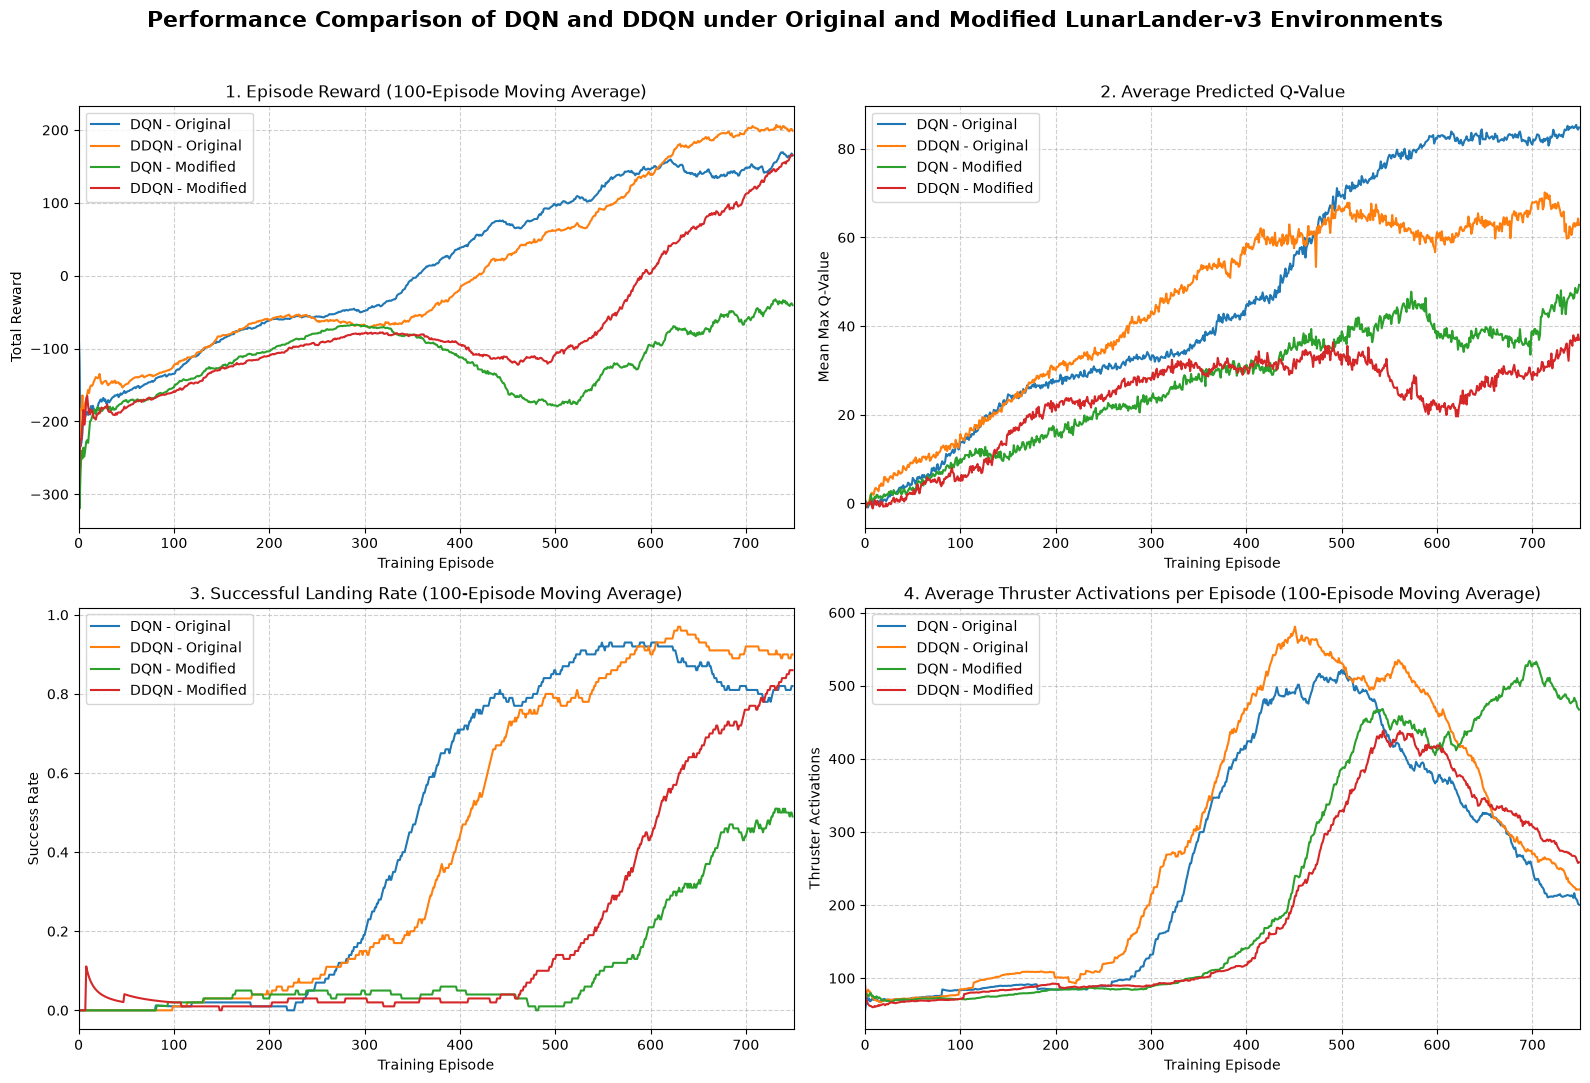

In [20]:
# ==========================================================
# Task (d): Performance Evaluation
# =========================================================
import pandas as pd
# ----------------------------------------------------------
# Moving Average Function
# ----------------------------------------------------------
def moving_average(series, window=100):
    """
    Computes moving average over the specified window.
    """
    return pd.Series(series).rolling(
        window=window,
        min_periods=1
    ).mean().values


num_episodes = len(dqn_original_rewards)

# ----------------------------------------------------------
# Create Figure
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

fig.suptitle(
    "Performance Comparison of DQN and DDQN under Original and Modified LunarLander-v3 Environments",
    fontsize=16,
    fontweight="bold"
)

# ==========================================================
# Plot 1 : Episode Reward vs Training Episode
# ==========================================================

axes[0,0].plot(
    moving_average(dqn_original_rewards),
    label="DQN - Original",
    linewidth=1.5
)

axes[0,0].plot(
    moving_average(ddqn_original_rewards),
    label="DDQN - Original",
    linewidth=1.5
)

axes[0,0].plot(
    moving_average(dqn_modified_rewards),
    label="DQN - Modified",
    linewidth=1.5
)

axes[0,0].plot(
    moving_average(ddqn_modified_rewards),
    label="DDQN - Modified",
    linewidth=1.5
)

axes[0,0].set_title("1. Episode Reward (100-Episode Moving Average)")
axes[0,0].set_xlabel("Training Episode")
axes[0,0].set_ylabel("Total Reward")
axes[0,0].set_xlim(0, num_episodes)
axes[0,0].legend()
axes[0,0].grid(True, linestyle="--", alpha=0.6)

# ==========================================================
# Plot 2 : Average Predicted Q-Value
# (Computed using the fixed validation set)
# ==========================================================

axes[0,1].plot(
    dqn_original_q_history,
    label="DQN - Original",
    linewidth=1.5
)

axes[0,1].plot(
    ddqn_original_q_history,
    label="DDQN - Original",
    linewidth=1.5
)

axes[0,1].plot(
    dqn_modified_q_history,
    label="DQN - Modified",
    linewidth=1.5
)

axes[0,1].plot(
    ddqn_modified_q_history,
    label="DDQN - Modified",
    linewidth=1.5
)

axes[0,1].set_title("2. Average Predicted Q-Value")
axes[0,1].set_xlabel("Training Episode")
axes[0,1].set_ylabel("Mean Max Q-Value")
axes[0,1].set_xlim(0, num_episodes)
axes[0,1].legend()
axes[0,1].grid(True, linestyle="--", alpha=0.6)

# ==========================================================
# Plot 3 : Successful Landing Rate
# ==========================================================

axes[1,0].plot(
    moving_average(dqn_original_success_history),
    label="DQN - Original",
    linewidth=1.5
)

axes[1,0].plot(
    moving_average(ddqn_original_success_history),
    label="DDQN - Original",
    linewidth=1.5
)

axes[1,0].plot(
    moving_average(dqn_modified_success_history),
    label="DQN - Modified",
    linewidth=1.5
)

axes[1,0].plot(
    moving_average(ddqn_modified_success_history),
    label="DDQN - Modified",
    linewidth=1.5
)

axes[1,0].set_title("3. Successful Landing Rate (100-Episode Moving Average)")
axes[1,0].set_xlabel("Training Episode")
axes[1,0].set_ylabel("Success Rate")
axes[1,0].set_xlim(0, num_episodes)
axes[1,0].legend()
axes[1,0].grid(True, linestyle="--", alpha=0.6)

# ==========================================================
# Plot 4 : Average Thruster Activations per Episode
# ==========================================================

axes[1,1].plot(
    moving_average(dqn_original_thruster_history),
    label="DQN - Original",
    linewidth=1.5
)

axes[1,1].plot(
    moving_average(ddqn_original_thruster_history),
    label="DDQN - Original",
    linewidth=1.5
)

axes[1,1].plot(
    moving_average(dqn_modified_thruster_history),
    label="DQN - Modified",
    linewidth=1.5
)

axes[1,1].plot(
    moving_average(ddqn_modified_thruster_history),
    label="DDQN - Modified",
    linewidth=1.5
)

axes[1,1].set_title("4. Average Thruster Activations per Episode (100-Episode Moving Average)")
axes[1,1].set_xlabel("Training Episode")
axes[1,1].set_ylabel("Thruster Activations")
axes[1,1].set_xlim(0, num_episodes)
axes[1,1].legend()
axes[1,1].grid(True, linestyle="--", alpha=0.6)

# ----------------------------------------------------------
# Display Figure
# ----------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Optional: Save figure for report
plt.savefig(
    "performance_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# (e) Discussion

## 1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN? Justify your answer using the Q-value plots.

Yes. The Q-value plots show a larger difference between the DQN and DDQN predictions in the **modified environment** than in the original environment. In the original environment, both algorithms exhibit steadily increasing Q-values, although DQN reaches higher predicted values. Under intermittent engine failures, the predicted Q-values for both algorithms are reduced, with **DDQN–Modified remaining noticeably lower than DQN–Modified** throughout most of training. This indicates that stochastic action failures make value estimation more difficult and increase the difference in the predicted Q-values of the two algorithms.

---

## 2. Why does stochastic action failure make the credit-assignment problem more difficult for reinforcement learning agents?

Stochastic engine failures introduce randomness between the selected action and the executed action. As a result, an agent may receive a poor reward even when it chooses the correct action because the environment executes a different action due to engine failure. This weakens the relationship between actions and their resulting rewards, making it harder for the agent to determine which actions are responsible for success or failure. Consequently, learning becomes slower and more unstable because the reward signal becomes noisier.

---

## 3. Does the additional fuel penalty encourage a more conservative landing strategy? Support your answer using experimental evidence.

Yes. The modified environment introduces an additional fuel penalty, encouraging agents to avoid unnecessary thruster activations. The thruster usage plots show that **both modified agents use fewer thruster activations than their original counterparts**, particularly during the later stages of training. Although this conservative behaviour reduces fuel consumption, it also results in slower learning, lower episode rewards, and lower landing success rates compared with the original environment. This suggests that the agents learned to balance landing performance with fuel efficiency.

---

## 4. Which algorithm performs better under stochastic engine failures? Is this behaviour consistent with the theoretical advantage of DDQN over DQN? Explain.

Based on the reward and landing-rate plots, **both DQN and DDQN adapt to stochastic engine failures**, but neither achieves the performance observed in the original environment. In the modified environment, both algorithms converge to similar final rewards, while **DQN reaches slightly higher final Q-values and a comparable or slightly higher final landing rate in this experiment**. Therefore, the experimental results do **not fully demonstrate the expected theoretical advantage of DDQN** under stochastic engine failures. The theoretical advantage of DDQN is its reduction of Q-value overestimation through separate action selection and evaluation, which often improves stability. However, in this experiment, the added environmental randomness appears to reduce the practical performance difference between the two algorithms.

---

## 5. Identify one limitation of your experimental setup and suggest one possible improvement.

**Limitation:** The experiments were conducted using a **single training run of 750 episodes**. Due to the stochastic nature of reinforcement learning, the results may be influenced by random initialization, exploration behaviour, and engine failures.

**Improvement:** Repeat the experiments using **multiple random seeds** and report the **mean and standard deviation** of the evaluation metrics (reward, Q-value, landing rate, and thruster usage). This would provide a more reliable comparison between DQN and DDQN and reduce the impact of randomness on the conclusions.